# Thematic Alignment in Scientific Journals
## A Case Study on the Journal of Machine Learning Research (JMLR)

This notebook implements a full pipeline to quantitatively assess whether 
papers published in JMLR align with its stated Aims & Scope.

The pipeline consists of four main steps:
1. **Data Collection** — fetch paper abstracts from Semantic Scholar API
2. **Text Embedding** — encode abstracts and Aims & Scope using Sentence-BERT
3. **Alignment Scoring** — compute cosine similarity for each paper
4. **Topic Modeling** — discover latent themes using BERTopic

Imports

In [47]:
import os
import numpy as np
import pandas as pd
from dotenv import load_dotenv

from src.fetcher import SemanticScholarFetcher
from src.embedder import TextEmbedder
from src.scorer import AlignmentScorer
from src.visualizer import Visualizer

load_dotenv()
print("All imports OK")

All imports OK


Aims & Scope

In [48]:
with open("data/aims_and_scope.txt", "r") as f:
    aims_and_scope = f.read()

print("Aims & Scope loaded.")
print(aims_and_scope)

Aims & Scope loaded.
The Journal of Machine Learning Research (JMLR) provides an international 
forum for the electronic and paper publication of high-quality scholarly 
articles in all areas of machine learning. All published papers are freely 
available online. JMLR seeks previously unpublished papers on machine 
learning that contain: new principled algorithms with sound empirical 
validation; experimental and/or theoretical studies yielding new insight 
into the design and behavior of learning in intelligent systems; accounts 
of applications of existing techniques that shed light on the strengths 
and weaknesses of known approaches; formalization of new learning tasks 
and presentation of new benchmarks; and developments of new analytical 
frameworks that advance theoretical studies on the complexity, geometry, 
and other mathematical properties of learning problems and algorithms.


Data Collection !

In [49]:
key = os.getenv("S2_API_KEY")
headers = {"x-api-key": key}

import requests, time

papers = []
token = None

while True:
    params = {
        "query": "machine learning",
        "venue": "Journal of Machine Learning Research",
        "fields": "title,abstract,year,venue",
        "limit": 100,
        "year": "2015-2024",
    }
    if token:
        params["token"] = token

    while True:
        response = requests.get(
            "https://api.semanticscholar.org/graph/v1/paper/search/bulk",
            params=params, headers=headers, timeout=30
        )
        if response.status_code == 429:
            print("Rate limit, waiting 60s...")
            time.sleep(60)
            continue
        break

    data = response.json()
    batch = data.get("data", [])
    token = data.get("token")

    for paper in batch:
        abstract = paper.get("abstract") or ""
        if len(abstract) > 50:
            papers.append({
                "paperId": paper.get("paperId", ""),
                "title": paper.get("title", ""),
                "abstract": abstract,
                "year": paper.get("year", 0),
                "venue": paper.get("venue", ""),
            })

    print(f"Collected: {len(papers)} papers")
    time.sleep(3)

    if not token:
        print("Done.")
        break

df = pd.DataFrame(papers).drop_duplicates(subset="paperId")
df.to_csv("data/abstracts.csv", index=False)
print(f"\nDataset shape: {df.shape}")
print(df["year"].value_counts().sort_index())

Collected: 345 papers
Done.

Dataset shape: (345, 5)
year
2015    24
2016    21
2017    20
2018    29
2019    32
2020    53
2021    62
2022    39
2023    43
2024    22
Name: count, dtype: int64


Load Data

In [50]:
df = pd.read_csv("data/abstracts.csv")
print(f"Dataset loaded: {df.shape}")
print(df["year"].value_counts().sort_index())

Dataset loaded: (345, 5)
year
2015    24
2016    21
2017    20
2018    29
2019    32
2020    53
2021    62
2022    39
2023    43
2024    22
Name: count, dtype: int64


Embeddings

In [51]:
embedder = TextEmbedder(model_name="all-MiniLM-L6-v2")

abstract_embeddings = embedder.encode_from_df(df, text_col="abstract")
scope_embedding = embedder.encode([aims_and_scope])[0]

np.save("data/embeddings.npy", abstract_embeddings)
np.save("data/scope_embedding.npy", scope_embedding)

print(f"Abstracts embeddings: {abstract_embeddings.shape}")
print(f"Scope embedding: {scope_embedding.shape}")

Loading model: all-MiniLM-L6-v2...
Model loaded.


Batches:   0%|          | 0/6 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Abstracts embeddings: (345, 384)
Scope embedding: (384,)


Load Embeddings

In [52]:
abstract_embeddings = np.load("data/embeddings.npy")
scope_embedding = np.load("data/scope_embedding.npy")
print(f"Embeddings loaded: {abstract_embeddings.shape}")

Embeddings loaded: (345, 384)


Alignment Scores

In [53]:
scorer = AlignmentScorer(scope_embedding=scope_embedding)
scores = scorer.compute_scores(abstract_embeddings)
df = scorer.add_scores_to_df(df, scores)

print(f"Mean:  {df['alignment_score'].mean():.4f}")
print(f"Std:   {df['alignment_score'].std():.4f}")
print(f"Min:   {df['alignment_score'].min():.4f}")
print(f"Max:   {df['alignment_score'].max():.4f}")

Mean:  0.3774
Std:   0.0679
Min:   0.1230
Max:   0.6022


Outliers

In [54]:
top, bottom = scorer.get_outliers(df, n=5)

print("TOP 5 — Most aligned:")
print(top[["title", "year", "alignment_score"]].to_string(index=False))

print("\nBOTTOM 5 — Least aligned:")
print(bottom[["title", "year", "alignment_score"]].to_string(index=False))

TOP 5 — Most aligned:
                                                         title  year  alignment_score
                                    The Bayesian Learning Rule  2021         0.602234
           Distributed Learning with Regularized Least Squares  2016         0.560884
                                    Approximate Newton Methods  2017         0.525894
Optimal Rates of Distributed Regression with Imperfect Kernels  2020         0.519323
              An Entropy-Based Model for Hierarchical Learning  2022         0.508918

BOTTOM 5 — Least aligned:
                                                                                               title  year  alignment_score
                                   Seglearn: A Python Package for Learning Sequences and Time Series  2018         0.224996
                                A Sharp Blockwise Tensor Perturbation Bound for Orthogonal Iteration  2020         0.202811
          Extracting PICO Sentences from Clinical Trial Reports

Topic Modeling

In [55]:
# ── Topic Modeling ────────────────────────────────────────
from bertopic import BERTopic
from sklearn.feature_extraction.text import CountVectorizer
from hdbscan import HDBSCAN

hdbscan_model = HDBSCAN(min_cluster_size=5, min_samples=3, prediction_data=True)
vectorizer = CountVectorizer(stop_words="english", min_df=2, ngram_range=(1, 2))

topic_model = BERTopic(
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer,
    nr_topics=10,
    calculate_probabilities=True,
    verbose=True,
)

abstracts = df["abstract"].fillna("").tolist()
topics, probs = topic_model.fit_transform(abstracts, embeddings=abstract_embeddings)
df["topic"] = topics

print(f"Topics found: {topic_model.get_topic_info().shape[0]}")
topic_model.get_topic_info()

2026-06-27 10:26:25,953 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-06-27 10:26:26,400 - BERTopic - Dimensionality - Completed ✓
2026-06-27 10:26:26,402 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-06-27 10:26:26,489 - BERTopic - Cluster - Completed ✓
2026-06-27 10:26:26,490 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-06-27 10:26:26,714 - BERTopic - Representation - Completed ✓
2026-06-27 10:26:26,716 - BERTopic - Topic reduction - Reducing number of topics
2026-06-27 10:26:26,737 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-06-27 10:26:26,881 - BERTopic - Representation - Completed ✓
2026-06-27 10:26:26,883 - BERTopic - Topic reduction - Reduced number of topics from 16 to 10


Topics found: 10


,Topic,Count,Name,Representation,Representative_Docs
0,-1,61,-1_learning_data_models_machine,"[learning, data, models, machine, machine lear...",[Quantile regression is a fundamental problem ...
1,0,107,0_convergence_learning_optimization_gradient,"[convergence, learning, optimization, gradient...",[This paper investigates asymptotic behaviors ...
2,1,66,1_learning_data_neural_machine,"[learning, data, neural, machine, models, mach...",[It is well established that neural networks w...
3,2,28,2_learning_causal_machine learning_machine,"[learning, causal, machine learning, machine, ...","[In contemporary statistical learning, covaria..."
4,3,21,3_python_library_learning_package,"[python, library, learning, package, scikitlea...",[DoubleML is an open-source Python library imp...
5,4,20,4_graph_graphs_data_learning,"[graph, graphs, data, learning, node, represen...",[Graph coarsening is a widely used dimensional...
6,5,15,5_optimization_problem_learning_bandit,"[optimization, problem, learning, bandit, prob...",[Learning to optimize (L2O) is an emerging app...
7,6,10,6_learning_automl_energy_ml,"[learning, automl, energy, ml, machine, model,...",[Automated Machine Learning (AutoML) supports ...
8,7,9,7_risk_treatment_optimal_value,"[risk, treatment, optimal, value, patients, sc...",[Data driven individualized decision making pr...
9,8,8,8_tensor_perturbation_bound_matrices,"[tensor, perturbation, bound, matrices, random...","[In statistics and machine learning, people ar..."


Visualizations

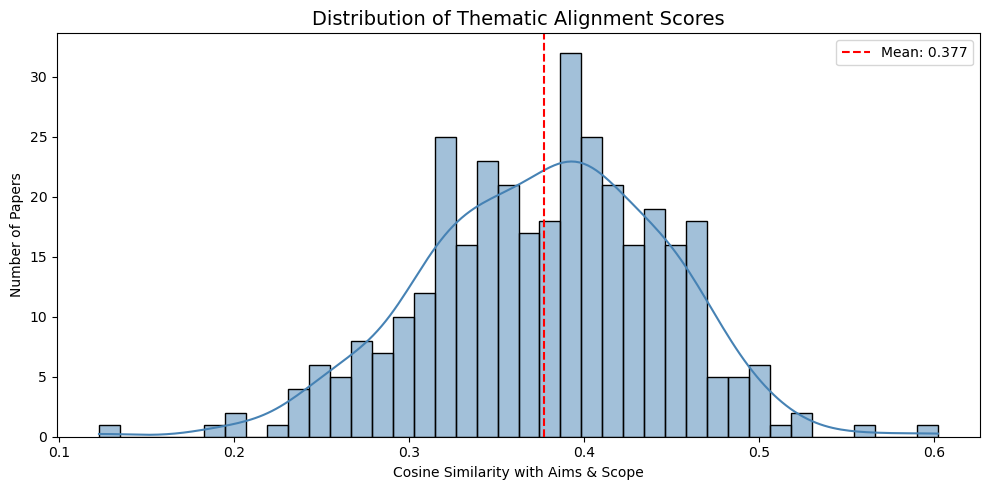

Saved: score_distribution.png


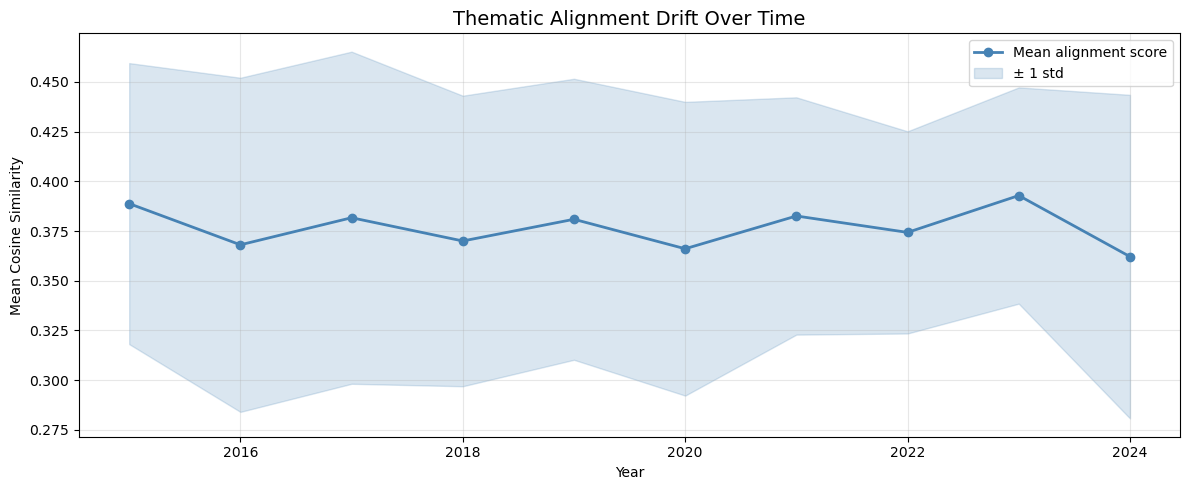

Saved: drift_over_time.png


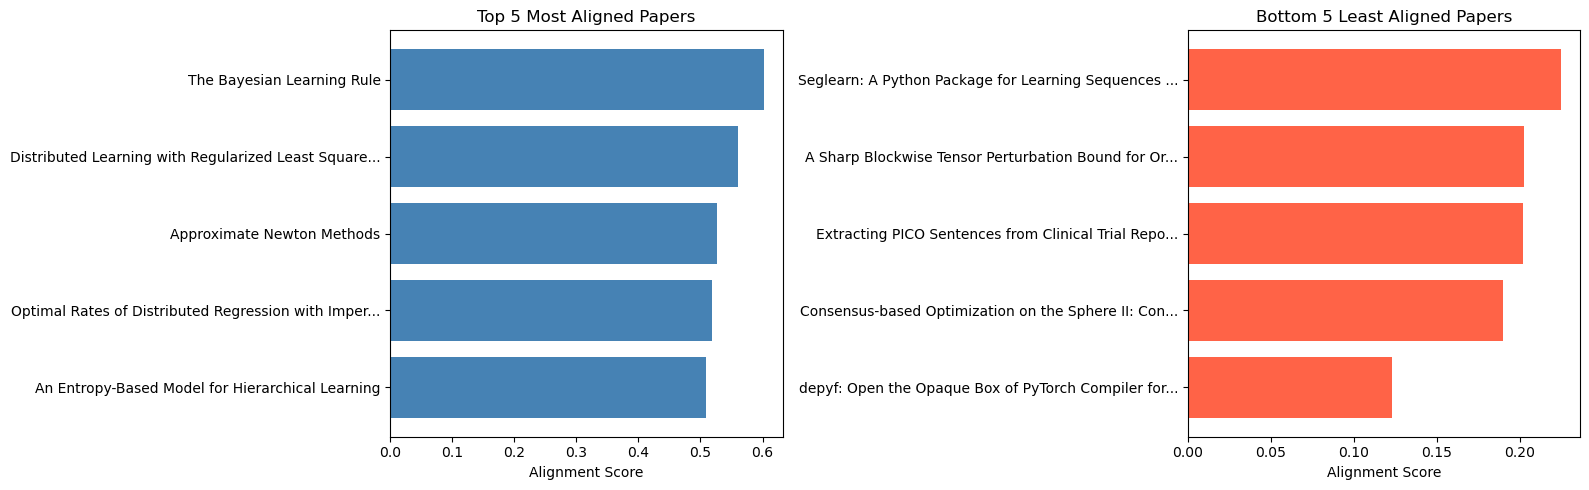

Saved: outliers.png


10it [00:00, 34.89it/s]


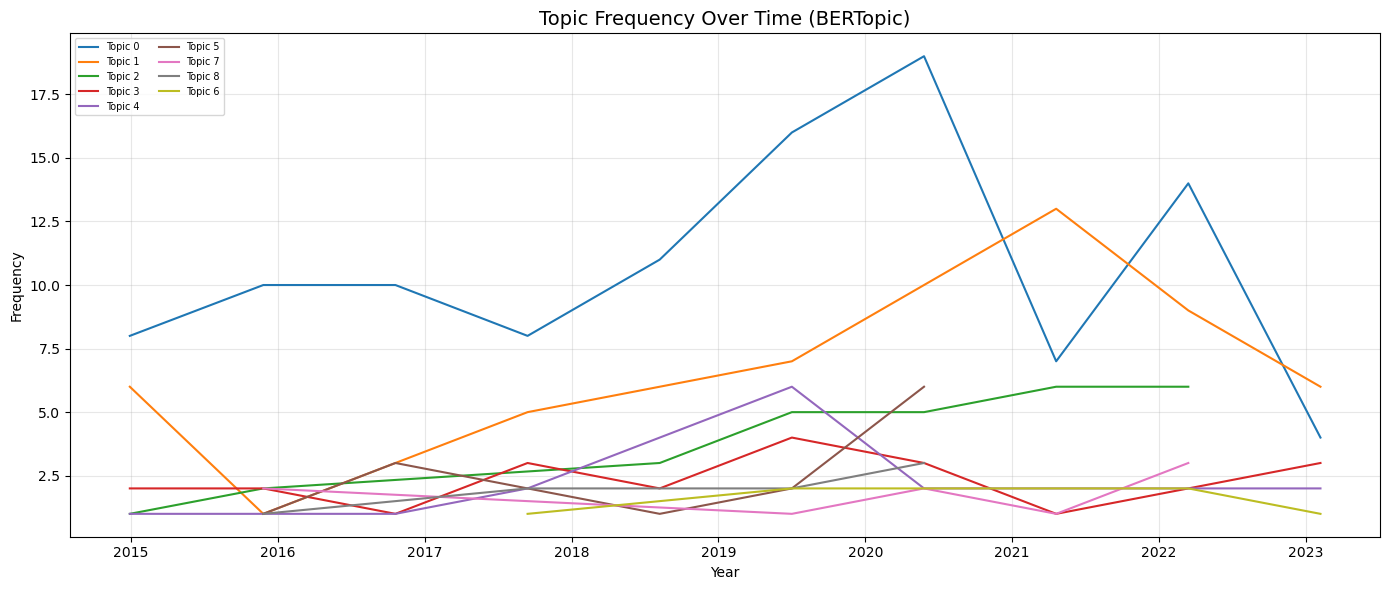

Saved: topics_over_time.png


In [56]:
# ── Visualizations ────────────────────────────────────────
viz = Visualizer(output_dir="figures")

viz.plot_score_distribution(df)
viz.plot_drift_over_time(df)
viz.plot_outliers(top, bottom)

topics_over_time = topic_model.topics_over_time(
    abstracts, df["year"].tolist(), nr_bins=10
)
viz.plot_topics_over_time(topics_over_time)

In [57]:
print("TOP 5 most aligned:")
for _, row in top.iterrows():
    print(f"  [{row['year']}] {row['title']}")

print("\nBOTTOM 5 least aligned:")
for _, row in bottom.iterrows():
    print(f"  [{row['year']}] {row['title']}")

TOP 5 most aligned:
  [2021] The Bayesian Learning Rule
  [2016] Distributed Learning with Regularized Least Squares
  [2017] Approximate Newton Methods
  [2020] Optimal Rates of Distributed Regression with Imperfect Kernels
  [2022] An Entropy-Based Model for Hierarchical Learning

BOTTOM 5 least aligned:
  [2018] Seglearn: A Python Package for Learning Sequences and Time Series
  [2020] A Sharp Blockwise Tensor Perturbation Bound for Orthogonal Iteration
  [2016] Extracting PICO Sentences from Clinical Trial Reports using Supervised Distant Supervision
  [2020] Consensus-based Optimization on the Sphere II: Convergence to Global Minimizers and Machine Learning
  [2024] depyf: Open the Opaque Box of PyTorch Compiler for Machine Learning Researchers
